# Malasanita in Italia - Preanalysis v3 (baseline raccomandata)
**Anno 2022 | Fonti: Ministero della Salute (A, C) + ISTAT (D)**

**Domanda:** Le regioni con meno personale sanitario hanno tassi più alti di mortalità evitabile?

Questa preanalysis usa la **v3** come metrica principale: broad age-standardization 30+ sulle stesse 12 cause Euro-2013 della v2.

La v3 è oggi la baseline raccomandata per il confronto inter-regionale per tre motivi:
- corregge meglio il confond demografico rispetto alla v2 grezza;
- elimina il denominatore ibrido su popolazione totale;
- produce un ranking regionale diverso in modo non cosmetico.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

cwd = Path.cwd().resolve()

# Root del filone in dataciviclab/analisi
analisi_root = next(
    (p for p in [cwd, *cwd.parents] if p.name == 'malasanita-struttura-mortalita'),
    None,
)
if analisi_root is None:
    raise FileNotFoundError('Non trovo la root di analisi/malasanita-struttura-mortalita')

# Contratto dati:
# 1) se MALASANITA_V3_PARQUET è impostata, usa quel path
# 2) altrimenti prova il path sibling di dataset-incubator
v3_env = os.getenv('MALASANITA_V3_PARQUET')
v2_env = os.getenv('MALASANITA_V2_PARQUET')

default_incubator_root = analisi_root.parents[2] / 'dataset-incubator'
default_v3 = default_incubator_root / 'out' / 'data' / 'mart' / 'malasanita_a_strutture_asl' / '2022' / 'mart_compose_regioni_v3.parquet'
default_v2 = default_incubator_root / 'out' / 'data' / 'mart' / 'malasanita_a_strutture_asl' / '2022' / 'mart_compose_regioni_v2.parquet'

MART_V3 = Path(v3_env) if v3_env else default_v3
MART_V2 = Path(v2_env) if v2_env else default_v2

missing = [str(p) for p in [MART_V3, MART_V2] if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Parquet non trovato. "
        "Imposta MALASANITA_V3_PARQUET e MALASANITA_V2_PARQUET, "
        "oppure tieni un checkout sibling di dataset-incubator con out/data già generato. "
        f"Path mancanti: {missing}"
    )

df = pd.read_parquet(MART_V3)
df_v2 = pd.read_parquet(MART_V2)
METRIC = 'tasso_std_broad_evitabile_100k_30plus'

print(f'Regioni/PA caricate: {len(df)} | Anno: {df["anno"].iloc[0]}')
print(f'Join C ok: {df["join_c_ok"].sum()}/21 | Join D ok: {df["join_d_ok"].sum()}/21')
print(f'Colonna mortalita: {METRIC}')

Regioni/PA caricate: 21 | Anno: 2022
Join C ok: 21/21 | Join D ok: 21/21
Colonna mortalita: tasso_std_broad_evitabile_100k_30plus


> **Nota metodologica preliminare**
>
> La fonte D non espone classi quinquennali, ma solo tre bande 30+: `30-69`, `70-84`, `85+`.
> La v3 standardizza le 12 cause Euro-2013 su queste tre bande usando pesi ESP2013 aggregati:
> `52.500`, `11.500`, `2.500` (totale `66.500`).
>
> Quindi la v3 è più difendibile della v2 grezza per confronto inter-regionale, ma resta più grossolana di una age-standardization piena a 5 anni.


## 1. Dove si concentra il proxy di rischio

La prima lettura utile è geografica: quali regioni mostrano i livelli più alti del tasso standardizzato broad?


In [2]:
rank = (
    df[['regione', METRIC, 'personale_osp_per_100k', 'medici_osp_per_100k', 'infermieri_per_100k', 'medici_mmg_per_100k', 'pediatri_per_100k']]
    .sort_values(METRIC, ascending=False)
    .reset_index(drop=True)
)
rank.index = rank.index + 1
rank.head(10)


,regione,tasso_std_broad_evitabile_100k_30plus,personale_osp_per_100k,medici_osp_per_100k,infermieri_per_100k,medici_mmg_per_100k,pediatri_per_100k
1,CAMPANIA,833.2,235.31,136.83,217.37,62.98,12.87
2,SICILIA,742.0,408.50,170.17,294.79,78.58,13.01
3,CALABRIA,722.6,381.09,142.93,283.11,71.14,12.50
4,BASILICATA,697.4,172.40,159.47,185.89,78.35,10.35
5,MOLISE,686.6,836.56,173.54,340.24,82.49,10.95
6,PUGLIA,660.4,303.78,162.33,232.45,76.96,13.13
7,ABRUZZO,656.0,310.75,192.88,426.43,75.71,10.66
8,PIEMONTE,647.4,180.79,149.35,272.56,65.50,8.60
9,LIGURIA,646.3,44.39,211.96,435.19,68.18,10.47
10,LAZIO,635.9,273.67,178.31,236.73,72.53,13.35


**Finding principale.** Con la v3 emergono soprattutto **Campania, Sicilia e Calabria**. Il ranking alto di queste regioni è più coerente con la geografia del rischio che il progetto sta cercando di misurare rispetto alla v2 grezza.

**Cautela.** Il Molise resta molto alto, ma va letto con prudenza: è una regione piccola, con outlier noti su alcune variabili strutturali e maggiore sensibilità alle oscillazioni del dato.


## 2. Cosa cambia davvero rispetto alla v2

Qui non interessa solo dire che la v3 è "più corretta": serve vedere se cambia qualcosa di sostanziale nella lettura del paese.


In [3]:
cmp = df[['regione', 'territorio_istat', METRIC]].merge(
    df_v2[['territorio_istat', 'decessi_evitabili_30plus_per_100k_pop_totale']],
    on='territorio_istat',
    how='left'
)
cmp['rank_v2'] = cmp['decessi_evitabili_30plus_per_100k_pop_totale'].rank(ascending=False, method='min')
cmp['rank_v3'] = cmp[METRIC].rank(ascending=False, method='min')
cmp['delta_rank'] = (cmp['rank_v3'] - cmp['rank_v2']).astype(int)
(
    cmp[['regione', 'rank_v2', 'rank_v3', 'delta_rank']]
    .assign(abs_shift=lambda x: x['delta_rank'].abs())
    .sort_values(['abs_shift', 'delta_rank'], ascending=[False, True])
)


,regione,rank_v2,rank_v3,delta_rank,abs_shift
15,CAMPANIA,11.0,1.0,-10,10
19,SICILIA,10.0,2.0,-8,8
7,LIGURIA,1.0,9.0,8,8
16,PUGLIA,12.0,6.0,-6,6
9,TOSCANA,13.0,19.0,6,6
10,UMBRIA,5.0,11.0,6,6
12,LAZIO,15.0,10.0,-5,5
18,CALABRIA,7.0,3.0,-4,4
0,PIEMONTE,4.0,8.0,4,4
6,FRIULI VENEZIA GIULIA,8.0,12.0,4,4


**Finding chiave.** Il passaggio da v2 a v3 non è  cosmetico.

- **Liguria** scende dal primo posto al nono: il dato grezzo era fortemente influenzato dalla struttura anziana della popolazione.
- **Campania** sale dal centro classifica al primo posto.
- **Sicilia** e **Calabria** salgono ai primi posti.

Questo è il motivo per cui la v3 viene promossa a baseline raccomandata: corregge un confond reale, non un dettaglio tecnico marginale.


## 3. Quanto si lega alla dotazione sanitaria

La domanda iniziale del progetto resta: meno personale sanitario coincide con livelli più alti di mortalità evitabile?

Qui serve rigore: il dataset consente una lettura esplorativa, non una prova causale.


In [4]:
corr_cols = ['personale_osp_per_100k', 'medici_osp_per_100k', 'infermieri_per_100k', 'medici_mmg_per_100k', 'pediatri_per_100k', METRIC]
corr = df[corr_cols].corr(numeric_only=True)[METRIC].drop(METRIC).sort_values()
corr.to_frame('corr_con_v3')


,corr_con_v3
medici_osp_per_100k,-0.433848
infermieri_per_100k,0.057977
pediatri_per_100k,0.125768
personale_osp_per_100k,0.213117
medici_mmg_per_100k,0.487561


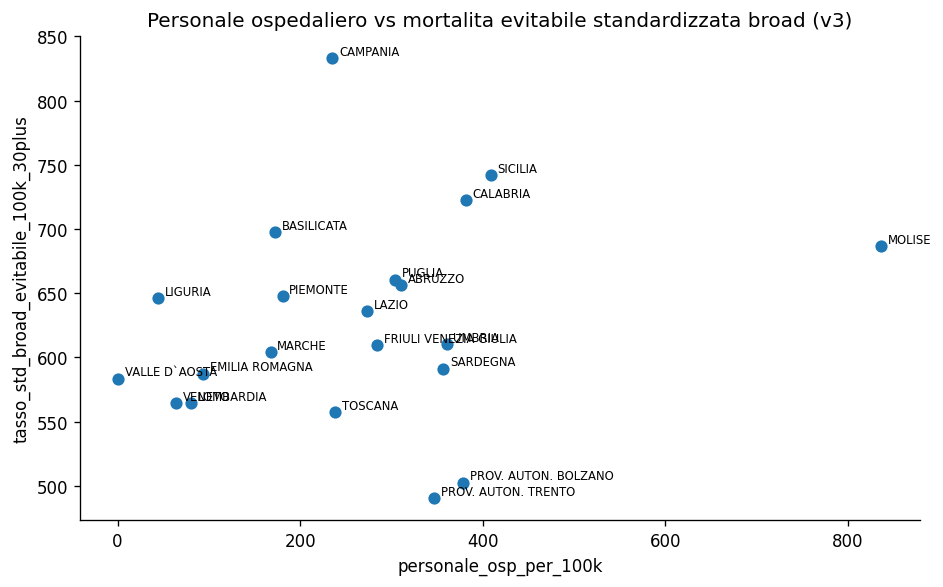

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['personale_osp_per_100k'], df[METRIC], s=40)
for _, r in df.iterrows():
    ax.annotate(r['regione'], (r['personale_osp_per_100k'], r[METRIC]), xytext=(4, 2), textcoords='offset points', fontsize=7)
ax.set_xlabel('personale_osp_per_100k')
ax.set_ylabel(METRIC)
ax.set_title('Personale ospedaliero vs mortalita evitabile standardizzata broad (v3)')
plt.tight_layout()
plt.show()


**Lettura prudente delle correlazioni.**

- `medici_osp_per_100k` è l'unica relazione chiaramente direzionale con il segno atteso (`-0.43`): più medici ospedalieri, minore mortalità evitabile standardizzata.
- Le altre correlazioni sono deboli o miste.
- `medici_mmg_per_100k` resta positiva: non è una prova contro l'ipotesi, ma un segnale che demografia, organizzazione territoriale e casi piccoli pesano ancora molto.

Quindi, allo stato attuale, il notebook supporta una conclusione sobria: **esiste un legame plausibile tra dotazione sanitaria e geografia del rischio, ma il segnale è ancora debole e confuso per parlare di causalità.**


## Conclusione

Con i dati strutturati disponibili oggi, la risposta più onesta alla domanda civica è questa:

- possiamo stimare un **proxy regionale difendibile del costo umano** della malasanita evitabile, usando la `v3` come baseline;
- possiamo mostrare **dove** questo proxy si concentra geograficamente nel 2022;
- possiamo confrontarlo con la dotazione sanitaria regionale, ma solo in chiave esplorativa.

**Non possiamo ancora fare due cose in modo pieno:**
- misurare il **costo economico** del contenzioso o degli errori medici;
- dimostrare un rapporto causale netto tra meno personale e più mortalità evitabile.

L’analisi restituisce una fotografia regionale del proxy di rischio nel 2022, con perimetro chiaro e limiti espliciti.
